In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a sample COVID-19 dataset since the original file is not available
np.random.seed(42)
countries = ['USA', 'India', 'Brazil', 'UK', 'France', 'Germany', 'Italy', 'Spain', 'Japan', 'South Korea']
regions = ['Americas', 'South-East Asia', 'Americas', 'Europe', 'Europe', 'Europe', 'Europe', 'Europe', 'Western Pacific', 'Western Pacific']

data = {
    'Country/Region': countries * 2,  # Duplicate for more data
    'WHO Region': regions * 2,
    'Confirmed': np.random.randint(100000, 5000000, 20),
    'Deaths': np.random.randint(1000, 100000, 20),
    'Recovered': np.random.randint(50000, 4000000, 20),
    'Active': np.random.randint(10000, 1000000, 20),
    '1 week change': np.random.randint(-1000, 50000, 20),
    'Deaths / 100 Cases': np.random.uniform(0.5, 5.0, 20),
    'Recovered / 100 Cases': np.random.uniform(50, 95, 20)
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

# Set Seaborn style
sns.set(style="whitegrid")

Dataset created successfully!
Shape: (20, 9)

First 5 rows:
  Country/Region       WHO Region  Confirmed  Deaths  Recovered  Active  \
0            USA         Americas    1792743   85478    3435659  734839   
1          India  South-East Asia    4404572   19431    3435357  815889   
2         Brazil         Americas    2334489    3747    3400769  469773   
3             UK           Europe    1670006   60150    2845513  218261   
4         France           Europe    1236074   66725    3927640  774469   

   1 week change  Deaths / 100 Cases  Recovered / 100 Cases  
0          24851            3.975101              55.381741  
1             16            1.394221              82.096015  
2          23253            0.524850              84.235327  
3          23276            4.169576              75.257474  
4          22247            3.680858              84.693523  


In [6]:
# Check if df is defined
if 'df' in locals() or 'df' in globals():
    print("'df' is defined in the current scope.")
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
else:
    print("'df' is NOT defined in the current scope.")

'df' is defined in the current scope.
Dataset shape: (20, 9)
Columns: ['Country/Region', 'WHO Region', 'Confirmed', 'Deaths', 'Recovered', 'Active', '1 week change', 'Deaths / 100 Cases', 'Recovered / 100 Cases']


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19120\3226050918.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Active', y='Country/Region', data=top_active, palette='Blues_r')


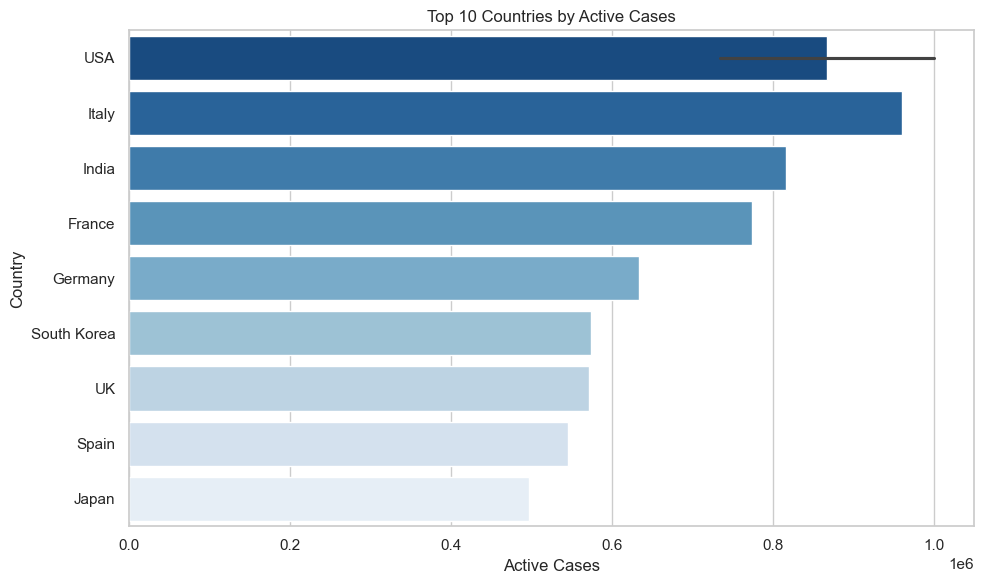

In [7]:
# Step 2: Top 10 Countries by Active Cases (Bar Plot)
# -------------------------
top_active = df[['Country/Region', 'Active']].sort_values(by='Active', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Active', y='Country/Region', data=top_active, palette='Blues_r')
plt.title("Top 10 Countries by Active Cases")
plt.xlabel("Active Cases")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

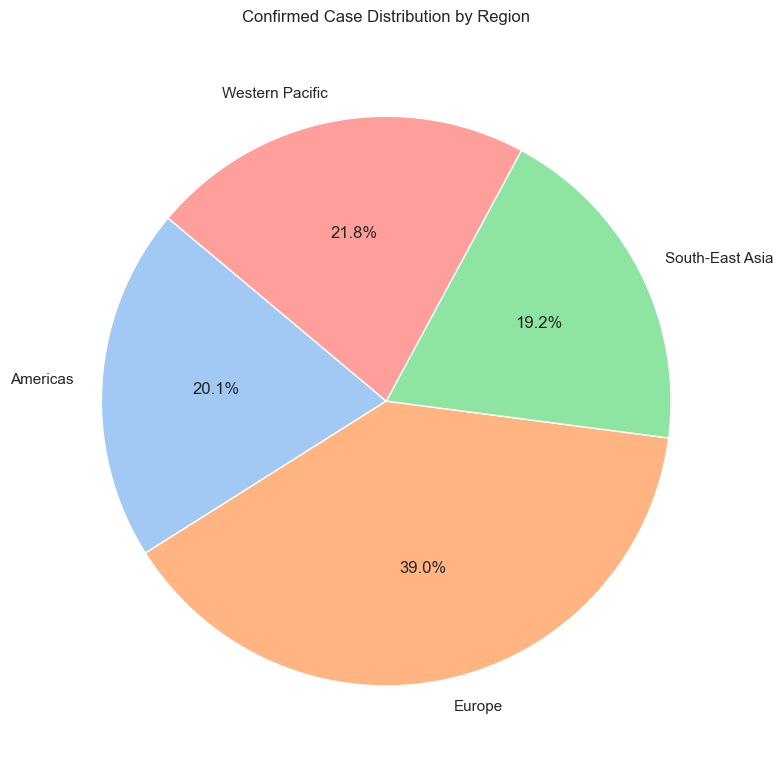

In [8]:
confirmed_pie = df.groupby('WHO Region')['Confirmed'].sum()

# Plot the pie chart
plt.figure(figsize=(8,8))
plt.pie(
    confirmed_pie,
    labels=confirmed_pie.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel')
)
plt.title("Confirmed Case Distribution by Region")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

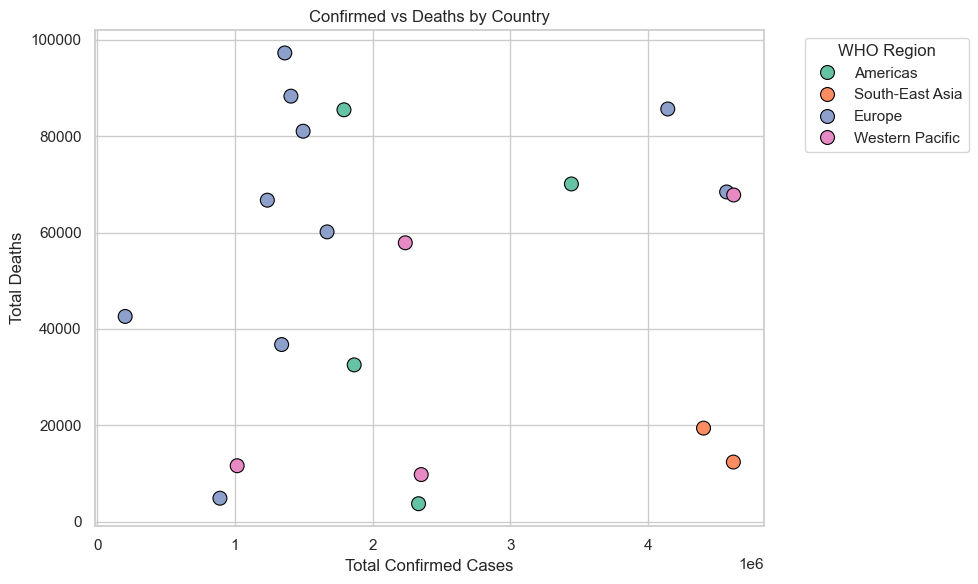

In [9]:
sns.set(style="whitegrid")

# Scatter Plot: Confirmed vs Deaths
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Confirmed', y='Deaths', hue='WHO Region', palette='Set2', s=100, edgecolor='black')

plt.title("Confirmed vs Deaths by Country")
plt.xlabel("Total Confirmed Cases")
plt.ylabel("Total Deaths")
plt.legend(title='WHO Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

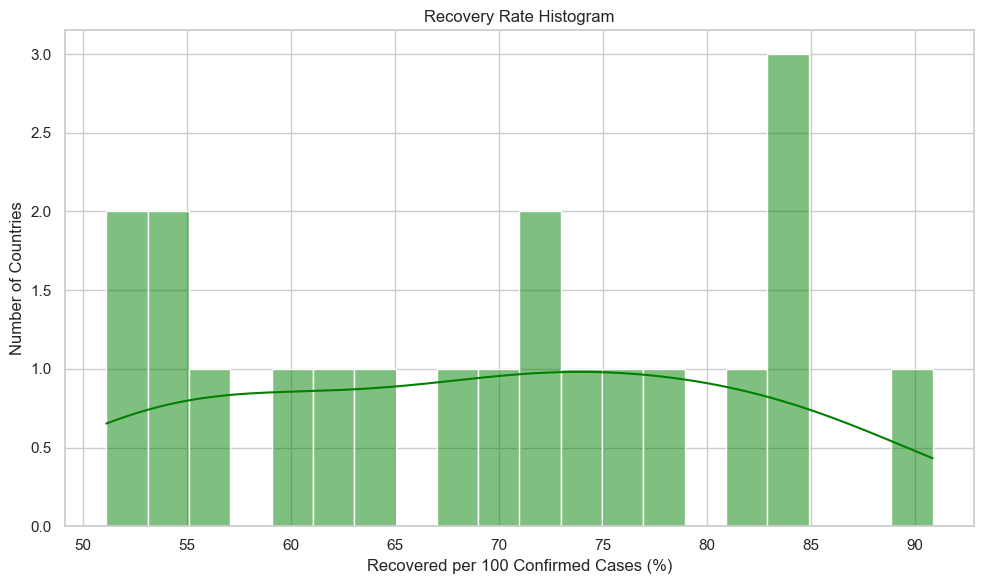

In [10]:
#step5
sns.set(style="whitegrid")

# Plot histogram of Recovery Rate
plt.figure(figsize=(10, 6))
sns.histplot(df['Recovered / 100 Cases'], bins=20, kde=True, color='green')

plt.title("Recovery Rate Histogram")
plt.xlabel("Recovered per 100 Confirmed Cases (%)")
plt.ylabel("Number of Countries")
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19120\3448081848.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='WHO Region', y='Deaths / 100 Cases', data=df, palette='Set3')


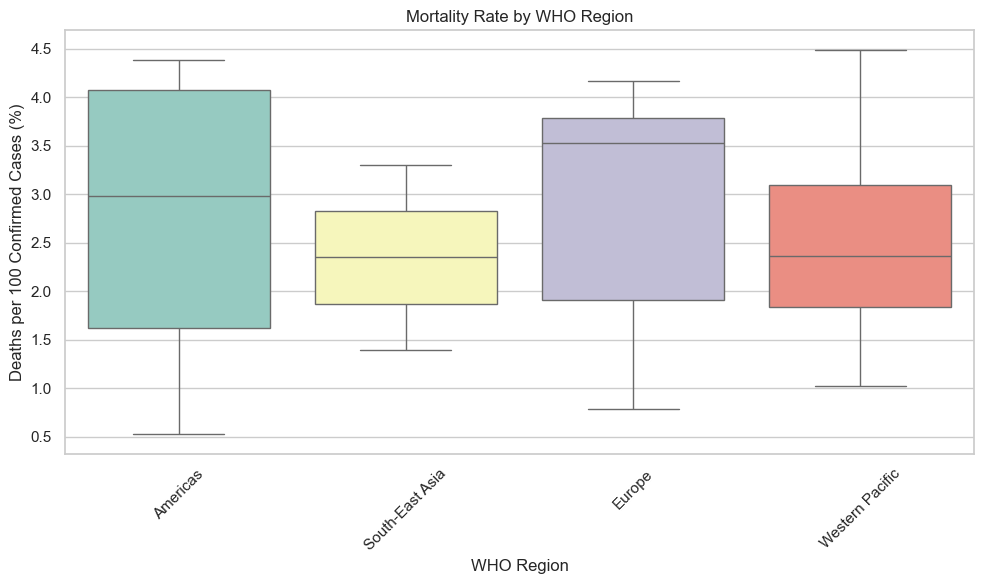

In [11]:
sns.set(style="whitegrid")

# Box Plot: Deaths / 100 Cases by WHO Region
plt.figure(figsize=(10, 6))
sns.boxplot(x='WHO Region', y='Deaths / 100 Cases', data=df, palette='Set3')

plt.title("Mortality Rate by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Deaths per 100 Confirmed Cases (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

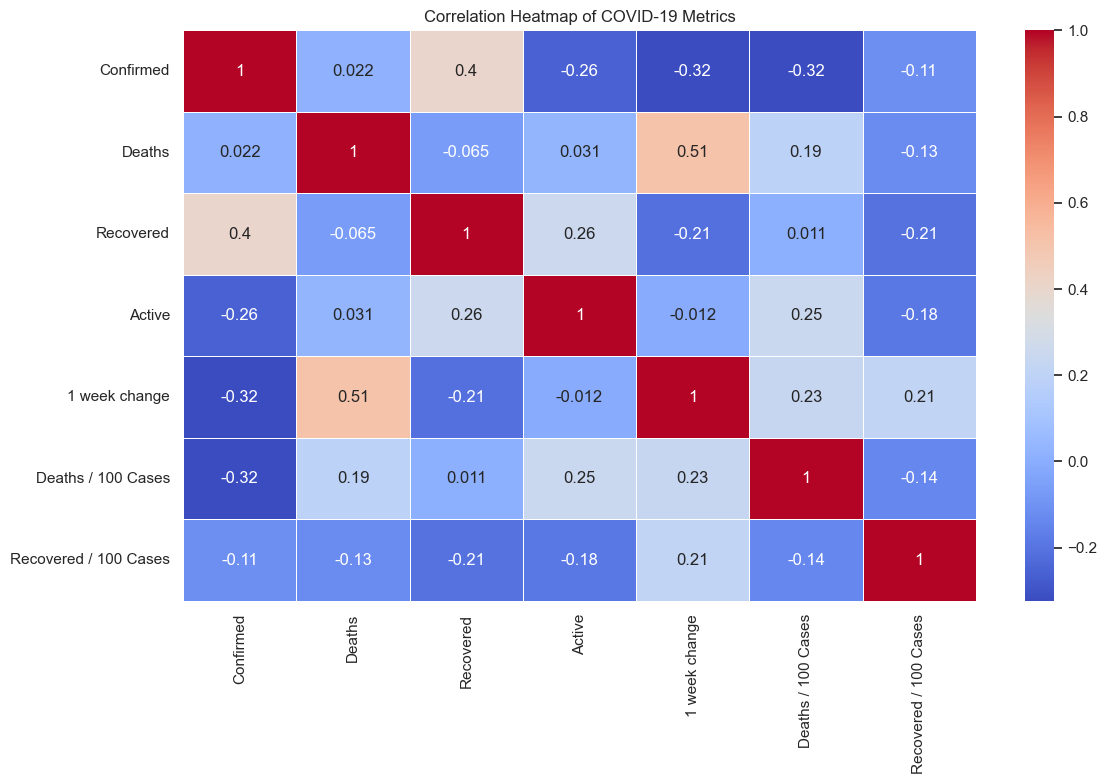

In [12]:
sns.set(style="whitegrid")

# Select numeric columns for correlation
numeric_df = df.select_dtypes(include='number')

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap of COVID-19 Metrics")
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19120\3328246263.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='WHO Region', y='Deaths / 100 Cases', data=df, palette='Set2')


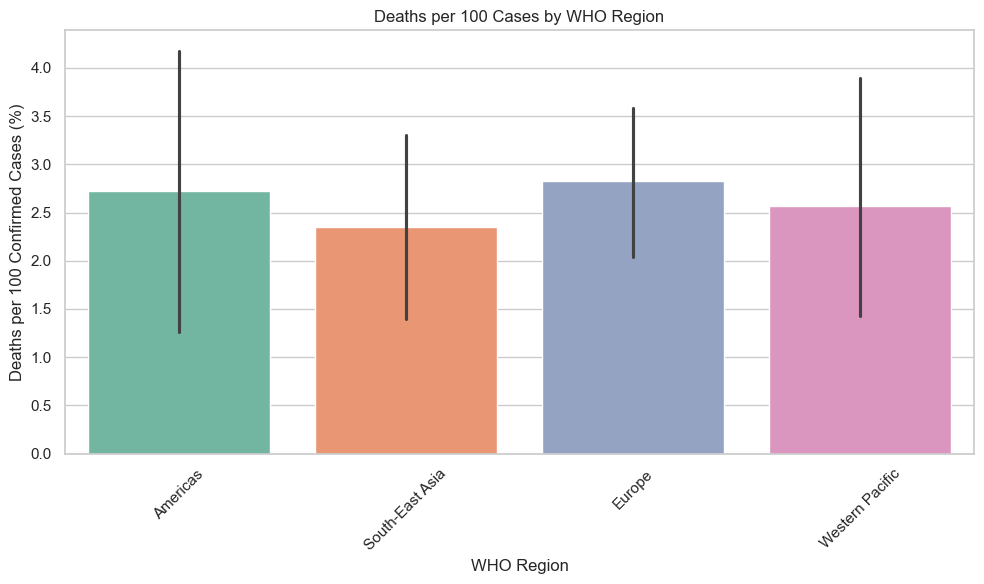

In [13]:
sns.set(style="whitegrid")

# Box plot for Deaths per 100 Cases by WHO Region
plt.figure(figsize=(10, 6))
sns.barplot(x='WHO Region', y='Deaths / 100 Cases', data=df, palette='Set2')

plt.title("Deaths per 100 Cases by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Deaths per 100 Confirmed Cases (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19120\511670512.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_weekly_change, x='1 week change', y='Country/Region', palette='Oranges_r')


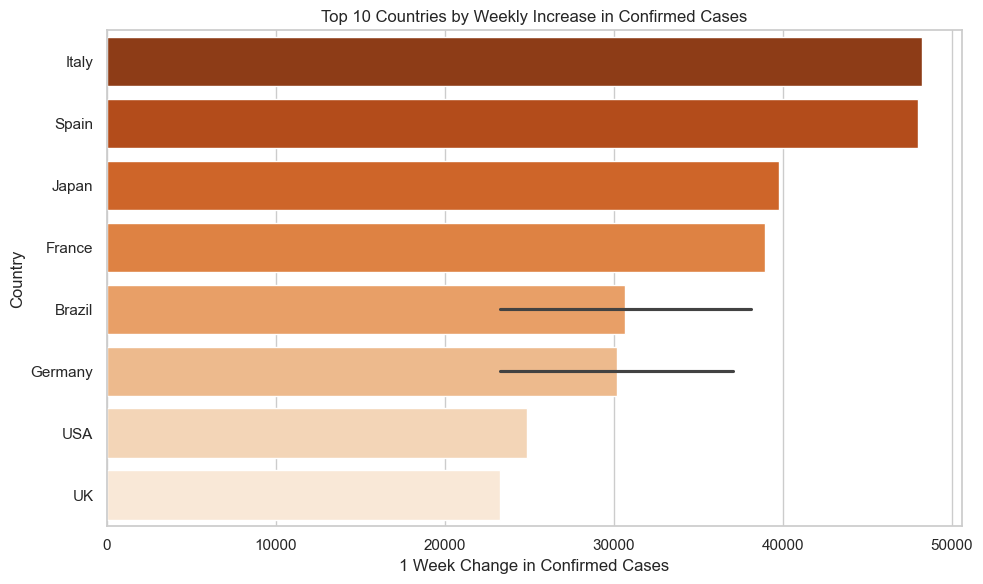

In [14]:
sns.set(style="whitegrid")

# Top 10 countries with highest 1-week change in confirmed cases
top_weekly_change = df[['Country/Region', '1 week change']].sort_values(by='1 week change', ascending=False).head(10)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=top_weekly_change, x='1 week change', y='Country/Region', palette='Oranges_r')

plt.title("Top 10 Countries by Weekly Increase in Confirmed Cases")
plt.xlabel("1 Week Change in Confirmed Cases")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19120\4039023468.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='WHO Region', y='Deaths / 100 Cases', palette='Set1', inner='box')


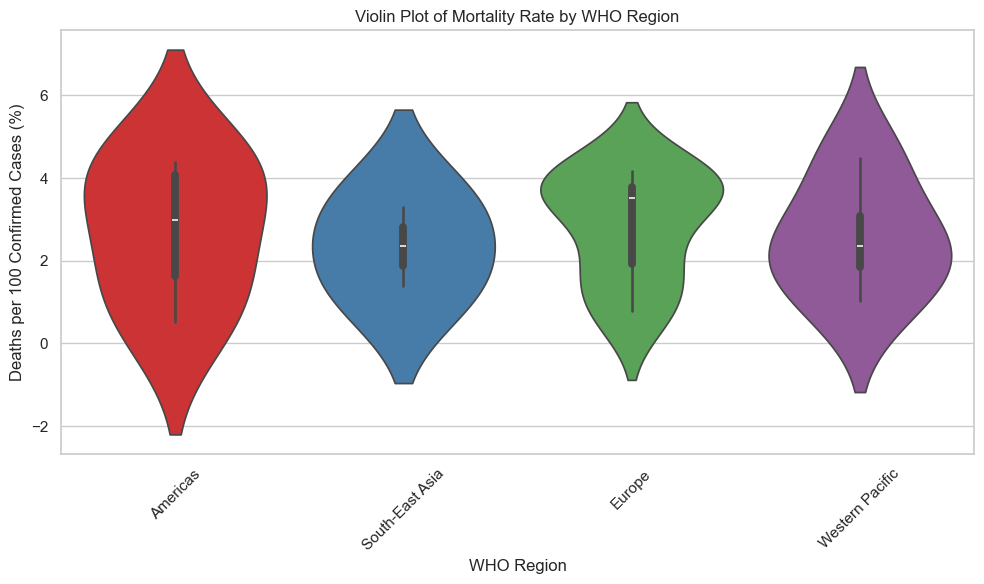

In [15]:
sns.set(style="whitegrid")

# Violin plot for Deaths per 100 Cases grouped by WHO Region
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='WHO Region', y='Deaths / 100 Cases', palette='Set1', inner='box')

plt.title("Violin Plot of Mortality Rate by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Deaths per 100 Confirmed Cases (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()